In [1]:
# cell 1
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Date handling
from datetime import datetime

# Plot style
sns.set(style="whitegrid")

# For reproducibility
RANDOM_STATE = 42

# File path: update this to your actual CSV file
DATA_PATH = "destiny_desserts_sales.csv"

In [2]:
# cell 2
# Attempt to load the CSV
try:
    df = pd.read_csv(DATA_PATH)
    print("Loaded data with shape:", df.shape)
except FileNotFoundError:
    print(f"File not found at {DATA_PATH}. Please check path or provide the CSV.")
    # Optionally create a small sample DataFrame below if needed

File not found at destiny_desserts_sales.csv. Please check path or provide the CSV.


In [3]:
# cell 3 (optional sample data generator)
np.random.seed(RANDOM_STATE)
n_samples = 500

sample_dates = pd.date_range(start="2024-01-01", periods=n_samples, freq="D")
age_groups = ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
genders = ["Male", "Female", "Other", "Prefer not to say"]
income_levels = ["Low", "Medium", "High"]

df_sample = pd.DataFrame({
    "date": np.random.choice(sample_dates, size=n_samples),
    # Simulate profit margin as percentage 5–50%
    "profit_margin_pct": np.random.uniform(5, 50, size=n_samples).round(1),
    # Demographics
    "age_group": np.random.choice(age_groups, size=n_samples),
    "gender": np.random.choice(genders, size=n_samples),
    "income_level": np.random.choice(income_levels, size=n_samples),
    # Simulate total sales: base + noise + small influence from profit_margin
    "total_sales": (
        200 +  # base daily sales
        np.random.normal(0, 50, size=n_samples) + 
        np.random.uniform(0.5, 2.0, size=n_samples) * np.random.uniform(5, 50, size=n_samples)
    ).round(2)
})

df = df_sample.copy()
print("Sample data shape:", df.shape)
df.head()

Sample data shape: (500, 6)


,date,profit_margin_pct,age_group,gender,income_level,total_sales
0,2024-04-12,11.3,45-54,Male,Medium,250.51
1,2025-03-11,28.3,25-34,Prefer not to say,Medium,199.10
2,2024-12-14,44.5,65+,Male,High,214.00
3,2024-09-27,38.3,Under 18,Female,Medium,148.01
4,2024-04-16,36.4,55-64,Prefer not to say,Medium,245.32


In [4]:
# cell 4
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               500 non-null    datetime64[ns]
 1   profit_margin_pct  500 non-null    float64       
 2   age_group          500 non-null    object        
 3   gender             500 non-null    object        
 4   income_level       500 non-null    object        
 5   total_sales        500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 23.6+ KB


,date,profit_margin_pct,age_group,gender,income_level,total_sales
count,500,500.000000,500,500,500,500.000000
unique,NaN,NaN,7,4,3,NaN
top,NaN,NaN,65+,Male,Medium,NaN
freq,NaN,NaN,77,136,176,NaN
mean,2024-09-09 02:55:40.800000256,27.332600,NaN,NaN,NaN,237.675760
min,2024-01-02 00:00:00,5.500000,NaN,NaN,NaN,65.870000
25%,2024-05-13 18:00:00,15.900000,NaN,NaN,NaN,202.805000
50%,2024-09-08 00:00:00,27.600000,NaN,NaN,NaN,235.330000
75%,2025-01-08 06:00:00,38.900000,NaN,NaN,NaN,271.415000
max,2025-05-14 00:00:00,50.000000,NaN,NaN,NaN,389.320000


In [5]:
# cell 5
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(df['date'].isna().sum(), "missing dates")

0 missing dates


In [6]:
# cell 6
# Example: drop rows with missing date or target
df = df.dropna(subset=['date', 'total_sales'])

# Optionally fill missing demographics with 'Unknown'
demo_cols = ['age_group', 'gender', 'income_level']
for col in demo_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [7]:
# cell 7
# Define custom range; update to actual desired dates
start_date = "2024-02-01"
end_date   = "2024-05-31"

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask].copy()
print("Records in custom range:", df_filtered.shape[0])

# Quick check: earliest and latest dates
print(df_filtered['date'].min(), df_filtered['date'].max())

Records in custom range: 124
2024-02-02 00:00:00 2024-05-31 00:00:00


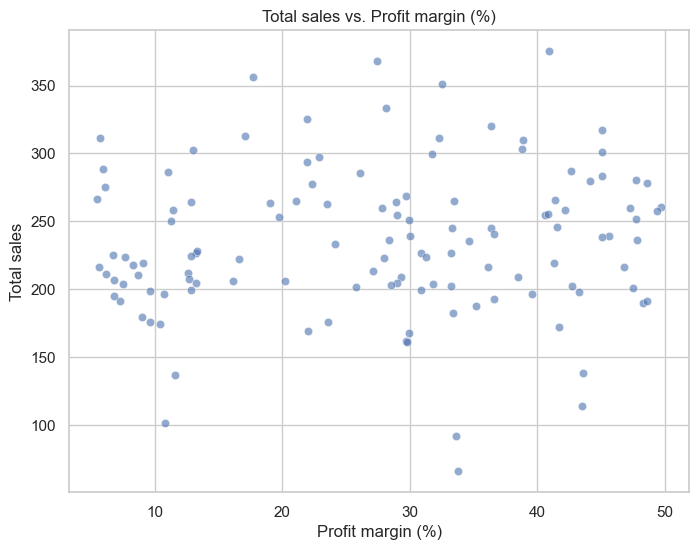

In [8]:
# cell 8
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_filtered,
    x="profit_margin_pct",
    y="total_sales",
    alpha=0.6
)
plt.title("Total sales vs. Profit margin (%)")
plt.xlabel("Profit margin (%)")
plt.ylabel("Total sales")
plt.show()

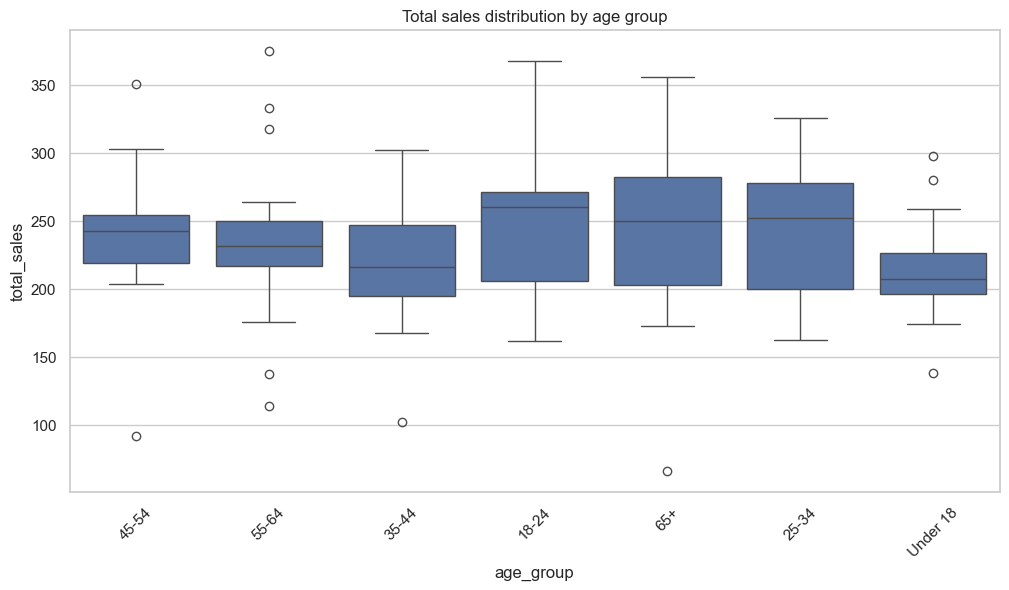

In [9]:
# cell 9
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_filtered,
    x="age_group", y="total_sales"
)
plt.title("Total sales distribution by age group")
plt.xticks(rotation=45)
plt.show()

In [10]:
# cell 11
target = "total_sales"
num_features = ["profit_margin_pct"]

cat_features = []
for col in ['age_group', 'gender', 'income_level']:
    if col in df_filtered.columns:
        cat_features.append(col)

print("Numeric:", num_features)
print("Categorical:", cat_features)

X = df_filtered[num_features + cat_features]
y = df_filtered[target]

Numeric: ['profit_margin_pct']
Categorical: ['age_group', 'gender', 'income_level']


In [11]:
# cell 12
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (99, 4) Test size: (25, 4)


In [12]:
# cell 13
# One-hot encode categorical, scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

In [13]:
# cell 14
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [14]:
# cell 15
y_pred = lr_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression -- RMSE: {rmse:.2f}, R²: {r2:.3f}")

Linear Regression -- RMSE: 52.25, R²: -0.122


In [15]:
# cell 16
# Coefficients for linear regression
# Extract feature names after preprocessing
feature_names_num = num_features
ohe = lr_pipeline.named_steps['preprocessor'].named_transformers_['cat']
feature_names_cat = ohe.get_feature_names_out(cat_features)
feature_names = list(feature_names_num) + list(feature_names_cat)

coefficients = lr_pipeline.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

coef_df.head(15)

,feature,coefficient
13,income_level_Low,13.494084
9,gender_Male,12.761198
6,age_group_65+,9.834035
5,age_group_55-64,7.379393
1,age_group_18-24,7.099557
2,age_group_25-34,1.304849
4,age_group_45-54,-0.229599
0,profit_margin_pct,-0.232602
10,gender_Other,-0.904567
14,income_level_Medium,-3.563785


In [16]:
# cell 17
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {
    "regressor__alpha": [0.1, 1.0, 10.0, 50.0]
}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)
print("Best alpha:", grid_ridge.best_params_)

Best alpha: {'regressor__alpha': 50.0}


In [17]:
# cell 18
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression -- RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.3f}")

Ridge Regression -- RMSE: 49.72, R²: -0.016


In [18]:
# cell 19
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter=5000))
])

param_grid_lasso = {
    "regressor__alpha": [0.01, 0.1, 1.0, 5.0]
}

grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)
print("Best Lasso alpha:", grid_lasso.best_params_)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression -- RMSE: {rmse_lasso:.2f}, R²: {r2_lasso:.3f}")

Best Lasso alpha: {'regressor__alpha': 5.0}
Lasso Regression -- RMSE: 49.46, R²: -0.005


In [19]:
# cell 20
# Using cross_val_score for the baseline LR model
cv_scores = cross_val_score(
    lr_pipeline, X, y, cv=5, scoring="r2", n_jobs=-1
)
print("Cross-validated R² scores:", cv_scores)
print("Mean R²:", cv_scores.mean(), "Std:", cv_scores.std())

Cross-validated R² scores: [-0.1234616  -0.15911275 -0.16762631 -0.51999234 -0.32108773]
Mean R²: -0.25825614337384584 Std: 0.1474221106504374


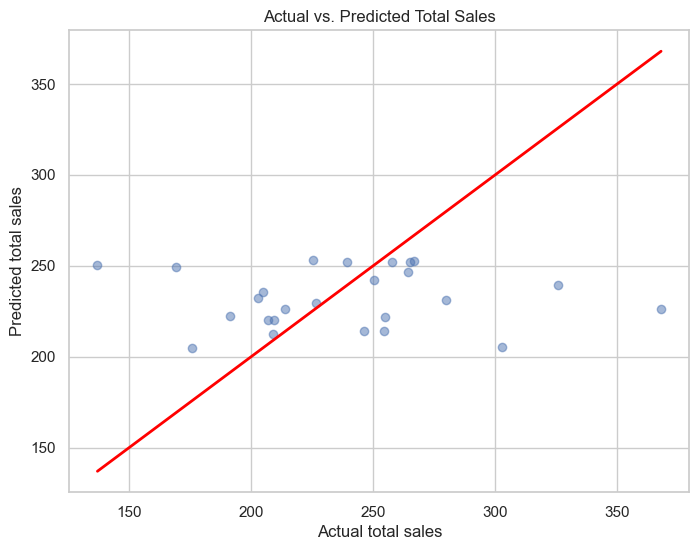

In [20]:
# cell 21
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2)
plt.xlabel("Actual total sales")
plt.ylabel("Predicted total sales")
plt.title("Actual vs. Predicted Total Sales")
plt.show()

In [21]:
# cell 22
# Example: fix profit_margin_pct to a certain value, vary demographics
margin_value = df_filtered['profit_margin_pct'].mean()

hypothetical = pd.DataFrame([
    {"profit_margin_pct": margin_value,
     "age_group": age,
     "gender": gender,
     "income_level": income}
    for age in age_groups
    for gender in genders
    for income in income_levels
])

# Some of these columns may be missing in the actual data; ensure consistency
for col in cat_features:
    if col not in hypothetical.columns:
        # Provide a default or skip
        hypothetical[col] = "Unknown"

# Predict
hypothetical_preds = lr_pipeline.predict(hypothetical[ num_features + cat_features ])

hypothetical['predicted_sales'] = hypothetical_preds
hypothetical.sort_values(by='predicted_sales', ascending=False).head(10)

,profit_margin_pct,age_group,gender,income_level,predicted_sales
72,27.471774,65+,Male,Low,268.729130
60,27.471774,55-64,Male,Low,266.274489
12,27.471774,18-24,Male,Low,265.994653
24,27.471774,25-34,Male,Low,260.199945
48,27.471774,45-54,Male,Low,258.665497
78,27.471774,65+,Other,Low,255.063366
66,27.471774,55-64,Other,Low,252.608724
81,27.471774,65+,Prefer not to say,Low,252.351386
18,27.471774,18-24,Other,Low,252.328888
73,27.471774,65+,Male,Medium,251.671262
